In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"   

from sklearn.model_selection import train_test_split

import keras_cv
import keras
import keras.backend as K
import tensorflow as tf
import tensorflow_io as tfio
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
import numpy as np 
import pandas as pd

from glob import glob
from tqdm import tqdm

import librosa
import IPython.display as ipd
import librosa.display as lid
from joblib import Parallel, delayed

import matplotlib.pyplot as plt
import matplotlib as mpl
cmap = mpl.colormaps['coolwarm']
import warnings
warnings.filterwarnings('ignore')

In [4]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


# Introduction

This problem and data are from the kaggle competetion, the link is https://www.kaggle.com/competitions/birdclef-2024

## Introduction to Problem

**Birds are excellent indicators of biodiversity change since they are highly mobile and have diverse habitat requirements. However, frequently conducting traditional observer-based bird biodiversity surveys over large areas is expensive and logistically challenging. In comparison, passive acoustic monitoring (PAM) combined with new analytical tools based on machine learning allows conservationists to sample much greater spatial scales with higher temporal resolution and explore the relationship between restoration interventions and biodiversity in depth. Plus a model that can identify species of birds is very cool. This project aims to build a deep learning model to identify Indian bird species as accuracy as possible. The loss will be evaluate by mean Average Precision (mAP)**

## Introduction to Data

# Exploratory Data Analysis (EDA)

## Inspect Data

In [5]:
BASE_PATH = '/kaggle/input/birdclef-2024'

### Metadata

In [6]:
df = pd.read_csv(f'{BASE_PATH}/train_metadata.csv')
print(df.shape)
df.head(2)

(24459, 12)


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,author,license,rating,url,filename
0,asbfly,[],['call'],39.2297,118.1987,Muscicapa dauurica,Asian Brown Flycatcher,Matt Slaymaker,Creative Commons Attribution-NonCommercial-Sha...,5.0,https://www.xeno-canto.org/134896,asbfly/XC134896.ogg
1,asbfly,[],['song'],51.4030,104.6401,Muscicapa dauurica,Asian Brown Flycatcher,Magnus Hellström,Creative Commons Attribution-NonCommercial-Sha...,2.5,https://www.xeno-canto.org/164848,asbfly/XC164848.ogg


In [7]:
df['filepath'] = BASE_PATH + '/train_audio/' + df.filename
print(df.shape)
df.head(2)

(24459, 13)


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,author,license,rating,url,filename,filepath
0,asbfly,[],['call'],39.2297,118.1987,Muscicapa dauurica,Asian Brown Flycatcher,Matt Slaymaker,Creative Commons Attribution-NonCommercial-Sha...,5.0,https://www.xeno-canto.org/134896,asbfly/XC134896.ogg,/kaggle/input/birdclef-2024/train_audio/asbfly...
1,asbfly,[],['song'],51.4030,104.6401,Muscicapa dauurica,Asian Brown Flycatcher,Magnus Hellström,Creative Commons Attribution-NonCommercial-Sha...,2.5,https://www.xeno-canto.org/164848,asbfly/XC164848.ogg,/kaggle/input/birdclef-2024/train_audio/asbfly...


### Encode Labels

In [8]:
class_names = sorted(os.listdir(f'{BASE_PATH}/train_audio/'))
num_classes = len(class_names)
class_labels = list(range(num_classes))
label2name = dict(zip(class_labels, class_names))
name2label = {v:k for k,v in label2name.items()}
print(num_classes)


182


In [9]:
df['target'] = df['primary_label'].map(name2label)
print(df.shape)
df[150:152]

(24459, 14)


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,author,license,rating,url,filename,filepath,target
150,ashdro1,[],['song'],15.1229,98.8928,Dicrurus leucophaeus,Ashy Drongo,Greg Irving,Creative Commons Attribution-NonCommercial-Sha...,5.0,https://www.xeno-canto.org/365197,ashdro1/XC365197.ogg,/kaggle/input/birdclef-2024/train_audio/ashdro...,1
151,ashdro1,[],['song'],12.8648,107.8017,Dicrurus leucophaeus,Ashy Drongo,Rolf A. de By,Creative Commons Attribution-NonCommercial-Sha...,5.0,https://www.xeno-canto.org/371163,ashdro1/XC371163.ogg,/kaggle/input/birdclef-2024/train_audio/ashdro...,1


In [10]:
img_size = [128, 384]
batch_size = 64
sample_rate = 32000
duration = 15
audio_len = duration*sample_rate
nfft = 2028
window = 2048
hop_length = audio_len // (img_size[1] - 1)
fmin = 20
fmax = 16000

### Inspect Audio Data

In [11]:
def get_spec(audio):
    spec = librosa.feature.melspectrogram(y=audio, 
                                   sr=sample_rate, 
                                   n_mels=256,
                                   n_fft=nfft,
                                   hop_length=hop_length,
                                   fmax=fmax,
                                   fmin=fmin,
                                   )
    spec = librosa.power_to_db(spec, ref=1.0)
    min_ = spec.min()
    max_ = spec.max()
    if max_ != min_:
        # normalize to 0 ~ 1
        spec = (spec - min_)/(max_ - min_)
    return spec
    
def display_audio(row):
    y, sr = librosa.load(row.filepath, sr=sample_rate) 
    y = y[:audio_len]
    print(f"Audio shape: {y.shape}, Sample rate: {sr}")
    # print(f"Audio Min: {y.min()}, Max: {y.max()}, Mean: {y.mean()}, Std: {y.std()}")

    
    print("Play Audio")
    ipd.display(ipd.Audio(y, rate=sr))
    
    # Visualize the waveform and spectrogram
    fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    fig.suptitle(row.common_name + ' | ' + row.primary_label)
    
    # Waveform
    lid.waveshow(y,
                 sr=sample_rate,
                 ax=ax[0],
                 color= cmap(0.1))

    # Spectrogram
    spec = get_spec(y)
    print(f"Spectrogram shape: {spec.shape}")
    # print(f"Spectrogram Min: {spec.min()}, Max: {spec.max()}")
    img = lid.specshow(
        spec, 
        sr=sample_rate, 
        hop_length=hop_length, 
        fmin=fmin, 
        fmax=fmax, 
        x_axis='time', 
        y_axis='mel', 
        cmap='coolwarm',
        ax=ax[1]
    )
    ax[1].set_title("Mel Spectrogram")
    # fig.colorbar(img, ax=ax[1], format='%+2.0f dB')

    plt.tight_layout() 
    plt.show()

    

Audio shape: (480000,), Sample rate: 32000
Play Audio


Spectrogram shape: (256, 384)


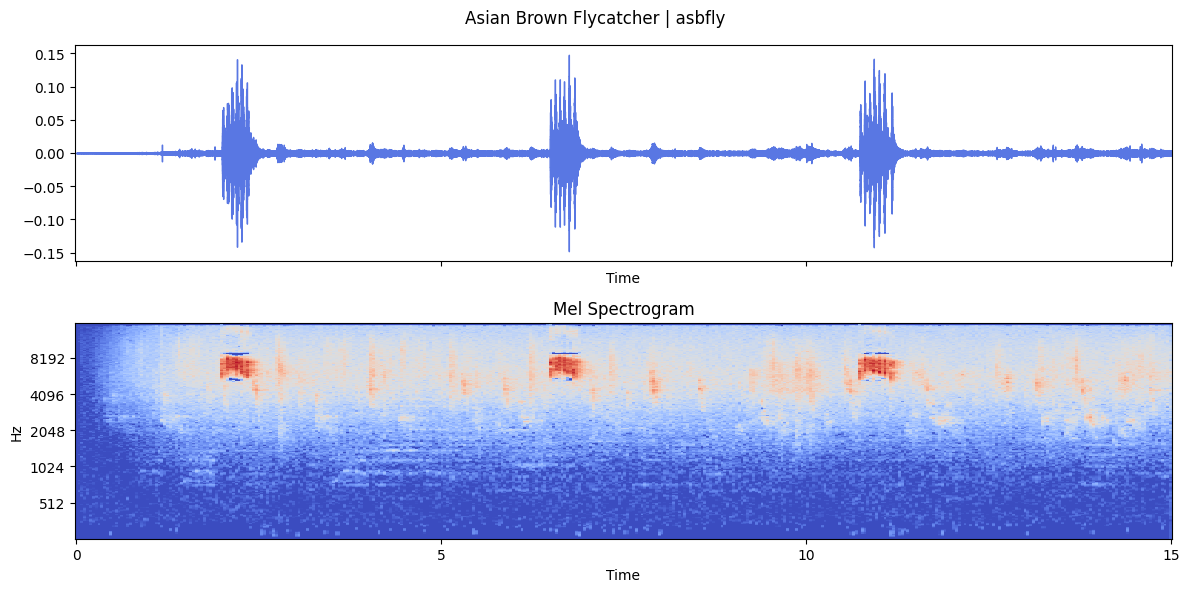

In [11]:
display_audio(df.iloc[0])

Audio shape: (289247,), Sample rate: 32000
Play Audio


Spectrogram shape: (256, 231)


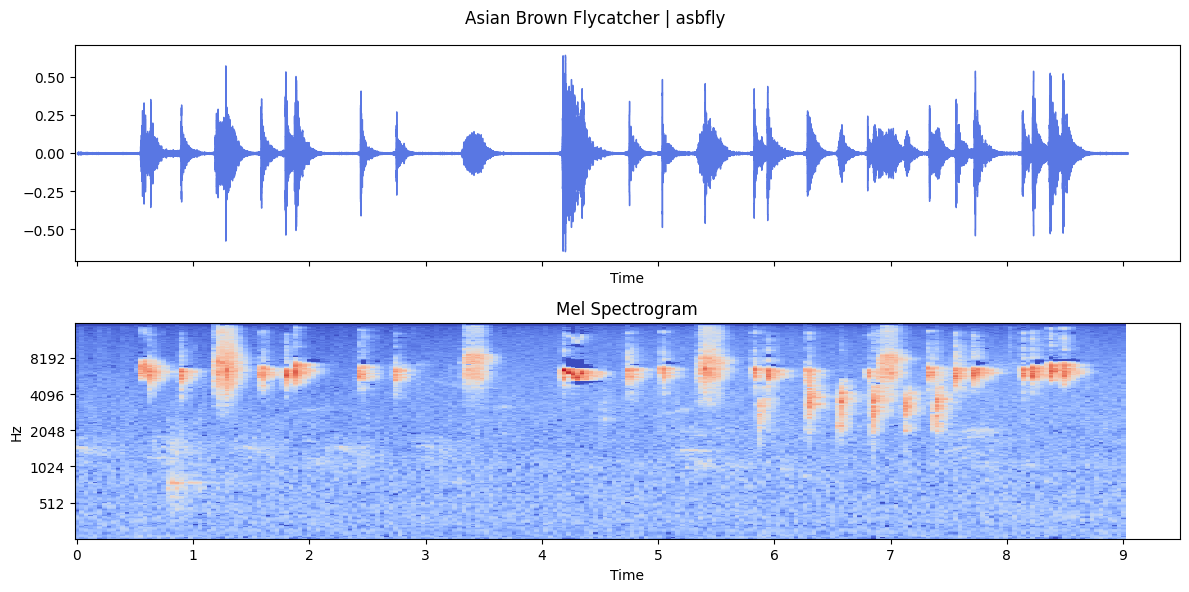

In [10]:
display_audio(df.iloc[100])

**This audio is shorter than 15seconds, we will pad short audio later**

Audio shape: (480000,), Sample rate: 32000
Play Audio


Spectrogram shape: (256, 384)


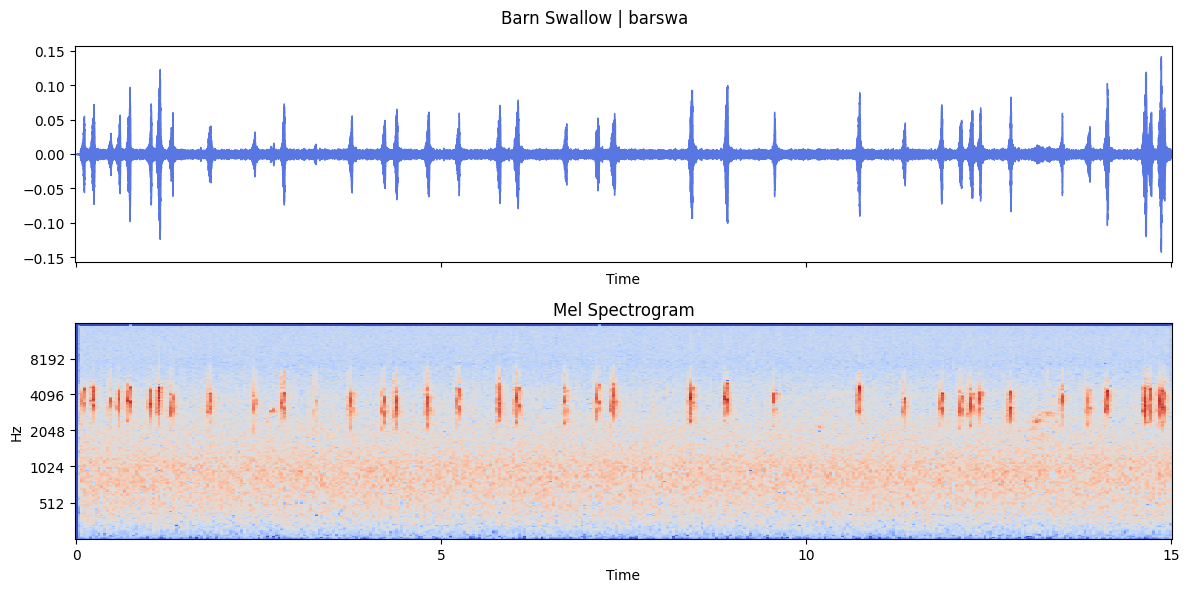

In [11]:
display_audio(df.iloc[1000])

## Clean Data

In [19]:
print(df.isnull().sum())

primary_label         0
secondary_labels      0
type                  0
latitude            378
longitude           378
scientific_name       0
common_name           0
author                0
license               0
rating                0
url                   0
filename              0
filepath              0
target                0
dtype: int64


**Since we will solely rely on audio signal to identify birds species, all columns in metadata are just for reference, expect the target value. In this case, we don't need to deal with missing value.**

## Explore Data

### Check Classes Distribution

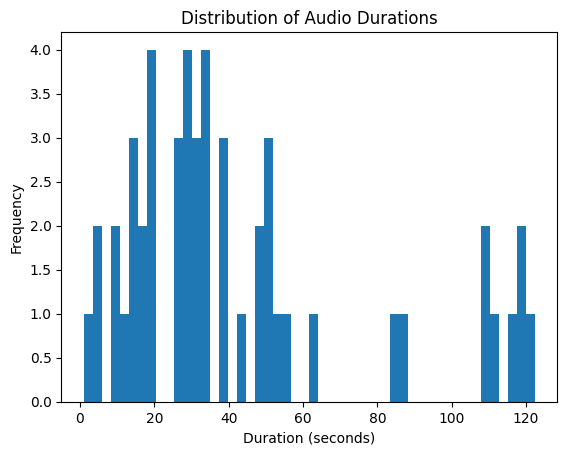

In [21]:

# durations = []
# for file in df['filepath'][:50]:
#     y, sr = librosa.load(file, sr=None)
#     durations.append(len(y) / sr) 

# plt.hist(durations, bins=50)
# plt.title('Distribution of Audio Durations')
# plt.xlabel('Duration (seconds)')
# plt.ylabel('Frequency')
# plt.show()

## Preprocess Data

In [12]:
def preprocess_audio_to_spec(audio_file, target_sr=32000, duration=15.0, img_size=(128, 384)):
    """
    Preprocess an audio file into a resized spectrogram for CNN input.
    """
    try:
        
        y, sr = librosa.load(audio_file, sr=target_sr, mono=True)
        max_length = int(target_sr * duration)
        y = y[:max_length] if len(y) > max_length else np.pad(y, (0, max_length - len(y)), 'constant')

        
        spec = librosa.feature.melspectrogram(
            y=y,
            sr=target_sr,
            n_mels=256,
            n_fft=nfft,
            hop_length=hop_length,
            fmin=fmin,
            fmax=fmax
        )
        spec = librosa.power_to_db(spec, ref=1.0)
        spec = (spec - spec.min()) / (spec.max() - spec.min() + 1e-6)  # Normalize to [0, 1]

        # Resize and format the spectrogram
        spec = tf.image.resize(spec[..., None], img_size).numpy()  
        spec = tf.tile(spec, [1, 1, 3]) 

        return spec
    except Exception as e:
        print(f"Error processing {audio_file}: {e}")
        return None



In [13]:
def build_tf_dataset(data_df, img_size=(128, 384), target_sr=32000, duration=15.0, batch_size=64, shuffle=True, is_train=True):
    
    
    def generator():
        for _, row in data_df.iterrows():
            spec = preprocess_audio_to_spec(row['filepath'], target_sr, duration, img_size)
            if spec is not None:
                if is_train:
                    yield spec, row['target']  
                else:
                    yield spec 

    
    if is_train:
        output_signature = (
            tf.TensorSpec(shape=(*img_size, 3), dtype=tf.float32), 
            tf.TensorSpec(shape=(), dtype=tf.int64) 
        )
    else:
        output_signature = tf.TensorSpec(shape=(*img_size, 3), dtype=tf.float32)  # Spectrogram only

    
    dataset = tf.data.Dataset.from_generator(generator, output_signature=output_signature)

    if shuffle and is_train:
        dataset = dataset.shuffle(1000)

    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    
    

In [14]:
train_df, val_df = train_test_split(df, test_size=0.2,random_state=42)

train_ds = build_tf_dataset(train_df, is_train=True, batch_size=64, shuffle=False)
val_ds = build_tf_dataset(val_df, is_train=True, batch_size=64, shuffle=False)



In [15]:
for X_batch, y_batch in train_ds.take(1):
    print(f"Spectrogram batch shape: {X_batch.shape}, Labels batch shape: {y_batch.shape}")
    

Spectrogram batch shape: (64, 128, 384, 3), Labels batch shape: (64,)


### Visualize

In [16]:
def visualize_batch(dataset, num_samples=9):
    
    # Take a single batch
    for spectrograms, labels in dataset.take(1): 
        spectrograms = spectrograms.numpy()  
        labels = labels.numpy()
        print(f"Spectrogram batch shape: {spectrograms.shape}")
        print(f"Labels batch shape: {labels.shape}")
        print(f"Sample spectrogram shape: {spectrograms[0].shape}")
        
        plt.figure(figsize=(15, 10))
        for i in range(min(num_samples, len(spectrograms))):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(spectrograms[i, :, :, 0], cmap='viridis', aspect='auto') 
            plt.title(f"Label: {label2name[labels[i]]}")
            plt.axis('off')
        plt.tight_layout()
        plt.show()
        break



Spectrogram batch shape: (64, 128, 384, 3)
Labels batch shape: (64,)
Sample spectrogram shape: (128, 384, 3)


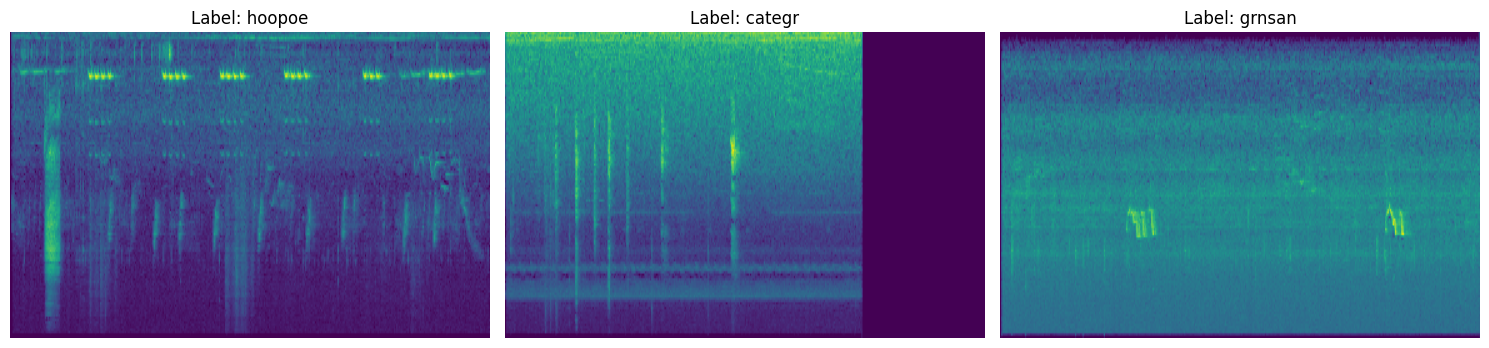

In [14]:
visualize_batch(train_ds,num_samples=3)

# Models

## Base Model

In [17]:

def build_cnn(input_shape=(128, 384, 3), num_classes=182):
    
    model = models.Sequential()

    # Convolutional Block 1
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.BatchNormalization())

    # Convolutional Block 2
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.BatchNormalization())

    # Convolutional Block 3
    # model.add(layers.Conv2D(128, (3, 3), activation='relu'))
    # model.add(layers.MaxPooling2D((2, 2)))
    # model.add(layers.BatchNormalization())

    # Flatten and Fully Connected Layers
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='softmax'))  

    return model


In [24]:

input_shape = (128, 384, 3) 

model = build_cnn(input_shape=input_shape, num_classes=num_classes)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', 
    # loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.02),
    # metrics=[keras.metrics.AUC(name='auc')],
    # metrics=['accuracy']
    # loss='mse',
    # metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top_5_accuracy')
    ]
)

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 126, 382, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 191, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 63, 191, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 61, 189, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 94, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 30, 94, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 180480)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    23,101,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 182)            │        23,478 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,144,822 (88.29 MB)

 Trainable params: 23,144,630 (88.29 MB)

 Non-trainable params: 192 (768.00 B)

In [25]:
dummy_input = tf.random.uniform((64, 128, 384, 3)) 
output = model(dummy_input)
print(f"Model output shape: {output.shape}")

Model output shape: (64, 182)


In [20]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
model_checkpoint = ModelCheckpoint(
    filepath='best_cnn_model.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    # mode='max'
)

In [26]:


# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    batch_size=batch_size,
    epochs=5,  
    callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/5
306/306 ━━━━━━━━━━━━━━━━━━━━ 2683s 9s/step - accuracy: 0.0179 - loss: 8.8695 - top_5_accuracy: 0.0889 - val_accuracy: 0.0031 - val_loss: 48.5098 - val_top_5_accuracy: 0.0331
Epoch 2/5
306/306 ━━━━━━━━━━━━━━━━━━━━ 2561s 8s/step - accuracy: 0.0203 - loss: 5.1931 - top_5_accuracy: 0.0952 - val_accuracy: 0.0170 - val_loss: 5.5851 - val_top_5_accuracy: 0.1032
Epoch 3/5
306/306 ━━━━━━━━━━━━━━━━━━━━ 2503s 8s/step - accuracy: 0.0223 - loss: 4.9235 - top_5_accuracy: 0.1004 - val_accuracy: 0.0161 - val_loss: 4.8636 - val_top_5_accuracy: 0.0991
Epoch 4/5
306/306 ━━━━━━━━━━━━━━━━━━━━ 2441s 8s/step - accuracy: 0.0221 - loss: 4.8415 - top_5_accuracy: 0.1015 - val_accuracy: 0.0186 - val_loss: 14.3323 - val_top_5_accuracy: 0.0830
Epoch 5/5
306/306 ━━━━━━━━━━━━━━━━━━━━ 2432s 8s/step - accuracy: 0.0218 - loss: 4.8406 - top_5_accuracy: 0.1024 - val_accuracy: 0.0161 - val_loss: 4.7600 - val_top_5_accuracy: 0.0908


In [ ]:
val_loss, val_accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {val_loss}, Validation Accuracy: {val_accuracy}, Validation Top 5 Accuracy: {val_top_5_accuracy}")

In [16]:
def plot_training_history(history):
    plt.figure(figsize=(12, 6))

    
    plt.subplot(1, 3, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    
    plt.subplot(1, 3, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(history.history['top_5_accuracy'], label='Train Top 5 Accuracy')
    plt.plot(history.history['val_top_5_accuracy'], label='Val Top 5 Accuracy')
    plt.title('Top 5 Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Top 5 Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()



In [27]:
history={"history": {"loss": [8.8695, 5.1931, 4.9235, 4.8415, 4.8406], 
         'val_loss': [48.5098, 5.5851, 4.8636, 14.3323, 4.7600], 
         'accuracy': [0.0179, 0.0203, 0.0223, 0.0221, 0.0218], 
         'val_accuracy': [0.0031, 0.0170, 0.0161, 0.0186, 0.0161],
         'top_5_accuracy': [0.0889, 0.0952, 0.1004, 0.1015, 0.1024],
         'val_top_5_accuracy': [0.0331, 0.1032, 0.0991, 0.0830, 0.0908]
         }}
history = pd.DataFrame(history)

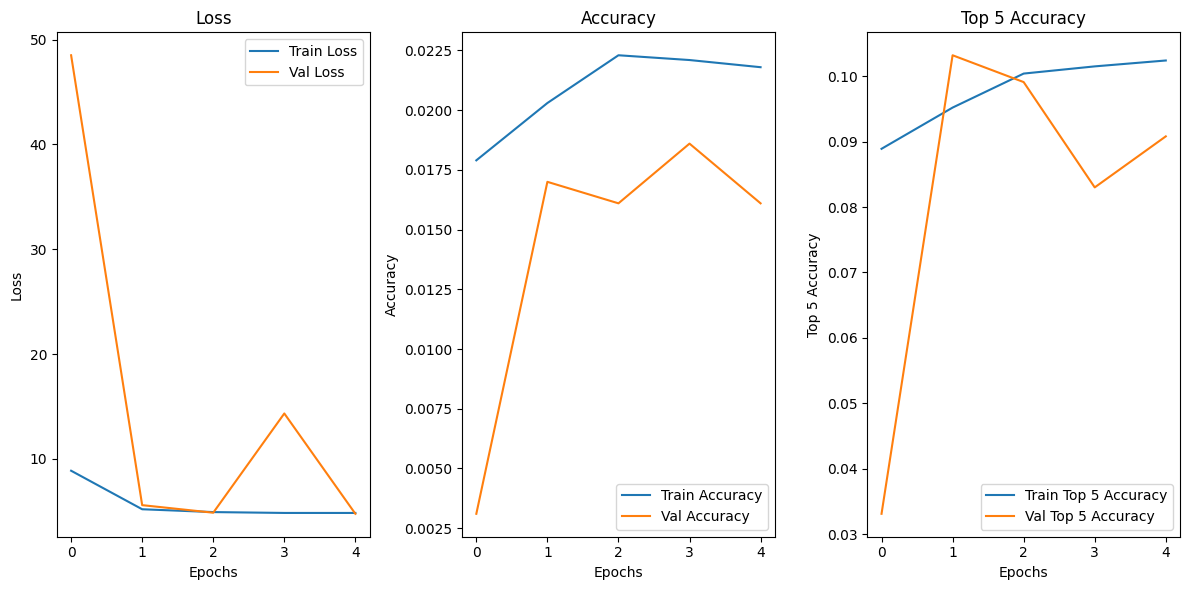

In [28]:
plot_training_history(history)

## Pretrained Model

We use effientnetB0

In [17]:
def build_pretrained_model(input_shape=(128, 384, 3), num_classes=182):
    
    inp = layers.Input(shape=input_shape)    
    x = preprocess_input(inp)  # Dynamically preprocess input

    backbone = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )
    backbone.trainable = False  # Freeze the backbone initially
    x = backbone(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    
    model = models.Model(inputs=inp, outputs=out)
    return model

In [18]:
pretrained_model = build_pretrained_model(input_shape=(128, 384, 3), num_classes=182)

pretrained_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top_5_accuracy')
    ]
)

pretrained_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 4, 12, 1280)    │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 182)            │       233,142 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,282,713 (16.34 MB)

 Trainable params: 233,142 (910.71 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [21]:
pretrained_history = pretrained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/5


I0000 00:00:1733263453.623880      97 service.cc:145] XLA service 0x7ff9ec002990 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1733263453.624004      97 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


      2/Unknown 40s 61ms/step - accuracy: 0.0117 - loss: 5.1999 - top_5_accuracy: 0.0352

I0000 00:00:1733263478.293828      97 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


306/306 ━━━━━━━━━━━━━━━━━━━━ 2804s 9s/step - accuracy: 0.0200 - loss: 4.7842 - top_5_accuracy: 0.0950 - val_accuracy: 0.0223 - val_loss: 4.6680 - val_top_5_accuracy: 0.0965
Epoch 2/5
306/306 ━━━━━━━━━━━━━━━━━━━━ 2524s 8s/step - accuracy: 0.0223 - loss: 4.6560 - top_5_accuracy: 0.1047 - val_accuracy: 0.0223 - val_loss: 4.6675 - val_top_5_accuracy: 0.0957
Epoch 3/5
306/306 ━━━━━━━━━━━━━━━━━━━━ 2502s 8s/step - accuracy: 0.0223 - loss: 4.6541 - top_5_accuracy: 0.1022 - val_accuracy: 0.0223 - val_loss: 4.6679 - val_top_5_accuracy: 0.0957
Epoch 4/5
306/306 ━━━━━━━━━━━━━━━━━━━━ 2518s 8s/step - accuracy: 0.0214 - loss: 4.6535 - top_5_accuracy: 0.1049 - val_accuracy: 0.0223 - val_loss: 4.6682 - val_top_5_accuracy: 0.0957
Epoch 5/5
306/306 ━━━━━━━━━━━━━━━━━━━━ 2585s 8s/step - accuracy: 0.0222 - loss: 4.6534 - top_5_accuracy: 0.1051 - val_accuracy: 0.0223 - val_loss: 4.6685 - val_top_5_accuracy: 0.1020


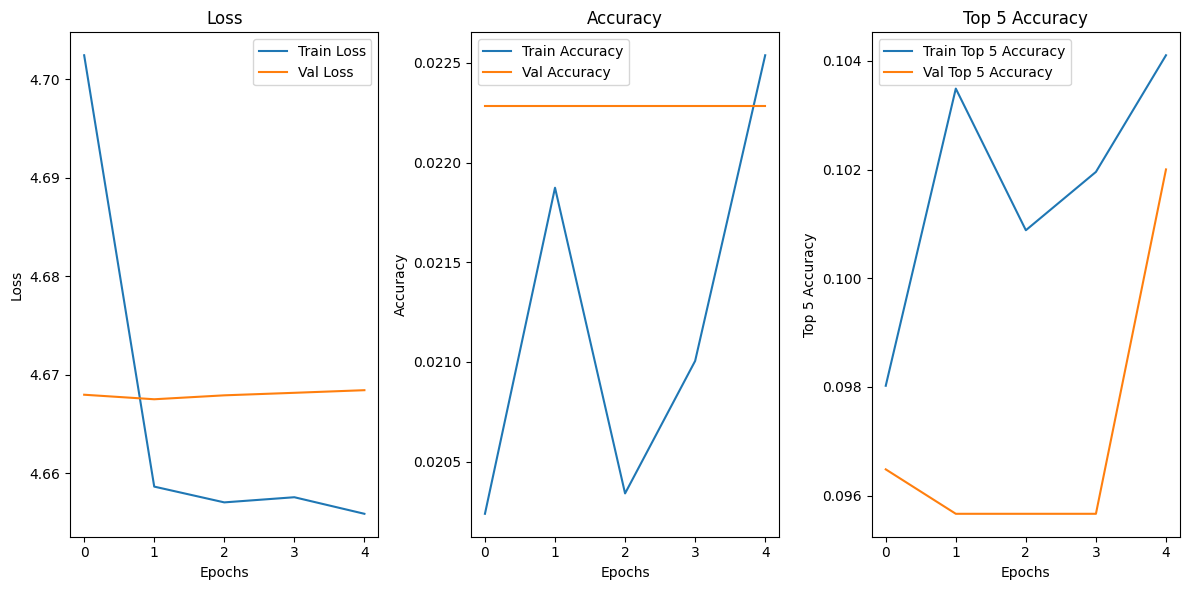

In [22]:
plot_training_history(pretrained_history)

# Result and Analysis

# Summary

# Reference

* https://keras.io/api/metrics/accuracy_metrics/#accuracy-metrics
* https://keras.io/guides/keras_cv/cut_mix_mix_up_and_rand_augment/
* https://keras.io/api/callbacks/model_checkpoint/
* https://www.kaggle.com/code/lenferdetroud/birdclef-2024
* https://www.kaggle.com/code/awsaf49/birdclef24-kerascv-starter-train
* https://www.kaggle.com/code/skanderkaroui/birdclef24-skander-s-attempt-train
* https://www.kaggle.com/code/indhujasidh/birdcleff24-stage-1
* 